# **Análisis y Limpieza de Datos Avocado.csv**


| Columna      | Descripción                                                                                          |
| ------------ | ---------------------------------------------------------------------------------------------------- |
| Unnamed: 0   | Índice generado automáticamente al exportar el dataset. No contiene información analítica relevante. |
| Date         | Fecha de observación del registro. Representa el periodo de venta.                                   |
| AveragePrice | Precio promedio de los aguacates en dólares para la región y fecha específica.                       |
| Total Volume | Volumen total de aguacates vendidos. Incluye ventas individuales y en bolsas.                        |
| 4046         | Número de aguacates vendidos del tipo PLU 4046 (generalmente tamaño pequeño).                        |
| 4225         | Número de aguacates vendidos del tipo PLU 4225 (generalmente tamaño mediano).                        |
| 4770         | Número de aguacates vendidos del tipo PLU 4770 (generalmente tamaño grande).                         |
| Total Bags   | Total de aguacates vendidos en bolsas. Es la suma de Small, Large y XLarge Bags.                     |
| Small Bags   | Número de aguacates vendidos en bolsas pequeñas.                                                     |
| Large Bags   | Número de aguacates vendidos en bolsas grandes.                                                      |
| XLarge Bags  | Número de aguacates vendidos en bolsas extra grandes.                                                |
| type         | Tipo de aguacate: conventional o organic.                                                            |
| year         | Año correspondiente al registro.                                                                     |
| region       | Región geográfica de las ventas. Puede representar ciudades, estados o regiones agregadas.           |


## 1. **Importación de Librerias**

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [134]:
df = pd.read_csv('avocado.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [135]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 2. **Exploración del Dataset**

In [136]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print()
df.info()

Dimensiones del dataset: (18249, 14)
Filas duplicadas: 0

Valores nulos por columna:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249

Se observa la existencia de una columna llamada "Unnamed: 0", la cual no aporta valor al análisis, ya que únicamente representa un índice generado automáticamente durante la exportación del dataset. Por lo tanto, esta columna se considera redundante y puede ser eliminada sin afectar la integridad de los datos.

In [137]:
# Eliminación de la columna 'Unnamed: 0'
df = df.drop(columns=['Unnamed: 0'])

In [138]:
df.describe()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


## 2. **Visualización de Valores Nulos**

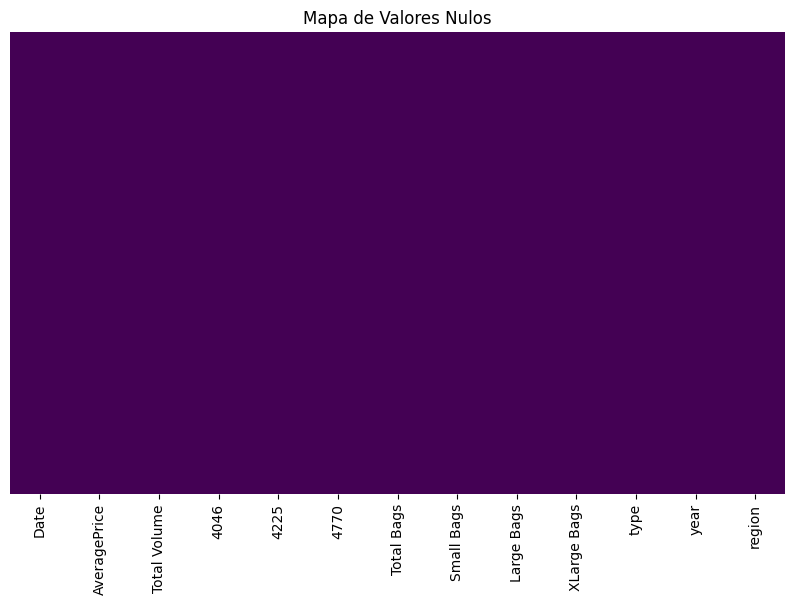

In [139]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Valores Nulos')
plt.show()

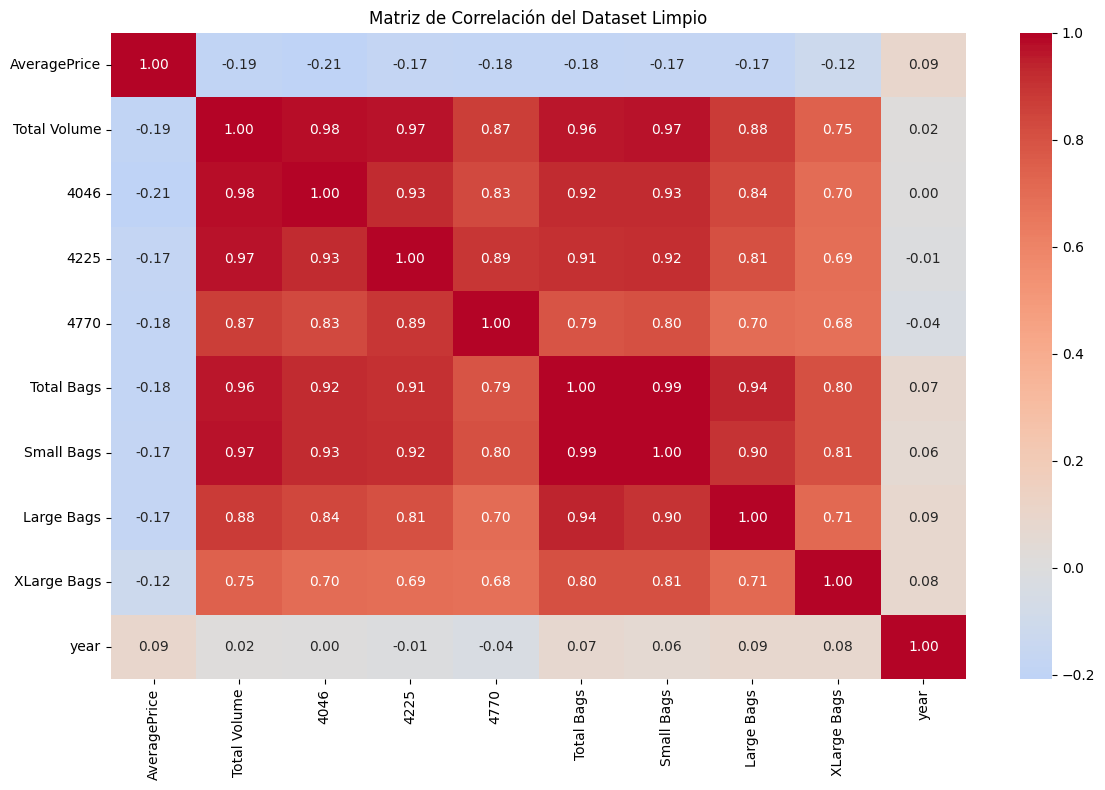

In [140]:
# Mapa de correlación del dataset limpio
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación del Dataset Limpio')
plt.tight_layout()
plt.show()

### *--> No se observan Valores Nulos*

## **4. Manejo de Duplicados**

In [141]:
# Detectar duplicados
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

Filas duplicadas encontradas: 0


### *--> No hay valores Duplicados*

In [142]:
df.type.value_counts()

type
conventional    9126
organic         9123
Name: count, dtype: int64

In [143]:
df.Date.value_counts()

Date
2015-12-27    108
2015-12-20    108
2015-12-13    108
2015-11-29    108
2015-11-22    108
             ... 
2018-02-04    108
2018-01-07    108
2015-12-06    107
2017-06-25    107
2017-06-18    107
Name: count, Length: 169, dtype: int64

## **5. Detección de Valores Atípicos**

### *5.1 Transformando Valores*

Según la descripción del dataset, las variables *Total Volume*, *4046*, *4225* y *4770*, representan el número total de aguacates vendidos.

Sin embargo, al observar los datos, se identifican valores decimales, lo cual sugiere que no se trata de conteos discretos exactos, sino de valores agregados, promedios o estimaciones del volumen de ventas.

Por esta razón, no se recomienda transformar estas variables a enteros, ya que los decimales contienen información relevante y su eliminación podría introducir errores en el análisis.


### *5.2 Comprobemos que las variables corresponden a su descripción*.

Analizando la estructura del Dataset y su composición se quiere llegar a comprender de donde provienen lo valores Total Volume y Total Bags realmente y si estos tienen consistencia en base a lo que se pueda intuir de ellos

#### *5.2.1 Transformemos a valores enteros*.


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  object 
 1   AveragePrice  18249 non-null  float64
 2   Total Volume  18249 non-null  float64
 3   4046          18249 non-null  float64
 4   4225          18249 non-null  float64
 5   4770          18249 non-null  float64
 6   Total Bags    18249 non-null  float64
 7   Small Bags    18249 non-null  float64
 8   Large Bags    18249 non-null  float64
 9   XLarge Bags   18249 non-null  float64
 10  type          18249 non-null  object 
 11  year          18249 non-null  int64  
 12  region        18249 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 1.8+ MB


In [145]:
#Conversión de columnas a tipo entero

df["Total Bags"] = df["Total Bags"].astype(int)
df["Total Volume"] = df["Total Volume"].astype(int)
df["4046"] = df["4046"].astype(int)
df["4225"] = df["4225"].astype(int)
df["4770"] = df["4770"].astype(int)
df["Small Bags"] = df["Small Bags"].astype(int)
df["Large Bags"] = df["Large Bags"].astype(int)
df["XLarge Bags"] = df["XLarge Bags"].astype(int)

#### **1° Comportamiento de *Total Volume***

Según la descripción del dataset, *Total Volume* corresponde a la cantidad total de aguacates vendidos. Esto se puede expresar como la suma de las diferentes categorías.

*df[Total Volume] = df[4046] + df[4225] + df[4770]*

Para comprobarlo, podemos calcular la suma de estas columnas y compararla con el valor registrado en *Total Volume* para cada fila del dataset.

In [146]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")

Discrepancia en fila 0: Total Volume = 64236, Calculado = 55538
Discrepancia en fila 1: Total Volume = 54876, Calculado = 45370
Discrepancia en fila 2: Total Volume = 118220, Calculado = 110073
Discrepancia en fila 3: Total Volume = 78992, Calculado = 73180
Discrepancia en fila 4: Total Volume = 51039, Calculado = 44854
Discrepancia en fila 5: Total Volume = 55979, Calculado = 49294
Discrepancia en fila 6: Total Volume = 83453, Calculado = 75133
Discrepancia en fila 7: Total Volume = 109428, Calculado = 102598
Discrepancia en fila 8: Total Volume = 99811, Calculado = 88422
Discrepancia en fila 9: Total Volume = 74338, Calculado = 65712
Discrepancia en fila 10: Total Volume = 84843, Calculado = 76636
Discrepancia en fila 11: Total Volume = 64489, Calculado = 54364
Discrepancia en fila 12: Total Volume = 61007, Calculado = 52249
Discrepancia en fila 13: Total Volume = 106803, Calculado = 100767
Discrepancia en fila 14: Total Volume = 69759, Calculado = 60491
Discrepancia en fila 15: Tota

Discrepancia en fila 3242: Total Volume = 628099, Calculado = 522369
Discrepancia en fila 3243: Total Volume = 626086, Calculado = 523670
Discrepancia en fila 3244: Total Volume = 644670, Calculado = 529446
Discrepancia en fila 3245: Total Volume = 614939, Calculado = 509323
Discrepancia en fila 3246: Total Volume = 658913, Calculado = 538305
Discrepancia en fila 3247: Total Volume = 717279, Calculado = 577795
Discrepancia en fila 3248: Total Volume = 712080, Calculado = 584533
Discrepancia en fila 3249: Total Volume = 974278, Calculado = 824982
Discrepancia en fila 3250: Total Volume = 860170, Calculado = 739566
Discrepancia en fila 3251: Total Volume = 882074, Calculado = 778425
Discrepancia en fila 3252: Total Volume = 770843, Calculado = 669757
Discrepancia en fila 3253: Total Volume = 885602, Calculado = 784035
Discrepancia en fila 3254: Total Volume = 958566, Calculado = 824774
Discrepancia en fila 3255: Total Volume = 903864, Calculado = 773736
Discrepancia en fila 3256: Total V

Como podemos observar, encontramos discrepancias desde la fila 0 entre los totales del dataset y los calculados manualmente. Pero, ¿por qué sucede esto? 

La razón es que existen variables adicionales que influyen en el cálculo de *Total Volume* y que inicialmente no fueron consideradas.

Para comprobarlo, tomemos en cuenta las columnas: *Total Bags*, *Small Bags*, *Large Bags* y *XLarge Bags*.

### **¿Por qué son importantes estas variables? ¿Qué representan?**

Al analizarlas, podemos concluir que estas variables hacen referencia a la cantidad de aguacates vendidos en diferentes tipos de empaque (bolsas):

- *Small Bags*: volumen vendido en bolsas pequeñas  
- *Large Bags*: volumen vendido en bolsas grandes  
- *XLarge Bags*: volumen vendido en bolsas extra grandes  

#### **2° Comportamiento de *Total Bags***
*Total Bags* corresponde a la cantidad total de aguacates vendidos en formato de bolsas. Esto se puede expresar intuitivamente como la suma de las diferentes categorías de bolsas.

*Total Bags = df [Small Bags] + df [Large Bags] + df [XLarge Bags]*

Para comprobarlo, podemos calcular la suma de estas columnas y compararla con el valor registrado en *Total Bags* para cada fila del dataset.

In [147]:
for i in range (len(df)): 
    total_calculated = df.loc[i, 'Small Bags'] + df.loc[i, 'Large Bags'] + df.loc[i, 'XLarge Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Bags']: 
        print(f"Discrepancia en fila {i}: Total Bags = {df.loc[i, 'Total Bags']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Bags.")

Discrepancia en fila 3: Total Bags = 5811, Calculado = 5810
Discrepancia en fila 7: Total Bags = 6829, Calculado = 6828
Discrepancia en fila 8: Total Bags = 11388, Calculado = 11387
Discrepancia en fila 10: Total Bags = 8205, Calculado = 8204
Discrepancia en fila 12: Total Bags = 8756, Calculado = 8755
Discrepancia en fila 13: Total Bags = 6034, Calculado = 6033
Discrepancia en fila 16: Total Bags = 7990, Calculado = 7989
Discrepancia en fila 17: Total Bags = 10306, Calculado = 10305
Discrepancia en fila 18: Total Bags = 10880, Calculado = 10879
Discrepancia en fila 19: Total Bags = 10443, Calculado = 10442
Discrepancia en fila 21: Total Bags = 11847, Calculado = 11846
Discrepancia en fila 23: Total Bags = 11287, Calculado = 11286
Discrepancia en fila 26: Total Bags = 26662, Calculado = 26661
Discrepancia en fila 29: Total Bags = 22775, Calculado = 22774
Discrepancia en fila 30: Total Bags = 23681, Calculado = 23680
Discrepancia en fila 31: Total Bags = 29355, Calculado = 29354
Discrep

Como podemos observar, encontramos discrepancias desde la fila 5621 en adelante entre los totales del dataset y los calculados manualmente.
Con el fin de corregir restas incosistencias sustituiremos los totales presentes en el dataset para *Total Bags* por los que calculamos manualmente

#### **EJEMPLO**

En la siguiente ejemplificación se muestra cómo se calculó la columna *Total Bags* y se verificó su consistencia con los valores de *Small Bags*, *Large Bags* y *XLarge Bags* para la fila 5673.

Al comparar el valor calculado con el registrado en el dataset, se observa una diferencia mínima de una unidad. Esta discrepancia amerita una corrección en los valores de Total Bags.

In [148]:
fila = 5673
tabla = pd.DataFrame({
    "Concepto": [
        "Total Bags (calculado)",
        "Total Bags (dataset)",
        "PLU 4046 + PLU 4225 + PLU 4770",
        "Total Volume (dataset)",
        "Total Volume (calculado)"
    ],
    "Valor": [
        df.loc[fila, 'Small Bags'] + df.loc[fila, 'Large Bags'] + df.loc[fila, 'XLarge Bags'],
        df.loc[fila, 'Total Bags'],
        df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770'],
        df.loc[fila, 'Total Volume'],
        (df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770']) + df.loc[fila, 'Total Bags']
    ]
})

tabla

,Concepto,Valor
0,Total Bags (calculado),207279
1,Total Bags (dataset),207280
2,PLU 4046 + PLU 4225 + PLU 4770,297654
3,Total Volume (dataset),504933
4,Total Volume (calculado),504934


##### **2.1° Corrigiendo *Total Bags***

In [149]:
df['Total Bags'] = df['Small Bags'] + df['Large Bags'] + df['XLarge Bags']

In [150]:
fila = 5673
tabla = pd.DataFrame({
    "Concepto": [
        "Total Bags (calculado)",
        "Total Bags (dataset)",
        "PLU 4046 + PLU 4225 + PLU 4770",
        "Total Volume (dataset)",
        "Total Volume (calculado)"
    ],
    "Valor": [
        df.loc[fila, 'Small Bags'] + df.loc[fila, 'Large Bags'] + df.loc[fila, 'XLarge Bags'],
        df.loc[fila, 'Total Bags'],
        df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770'],
        df.loc[fila, 'Total Volume'],
        (df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770']) + df.loc[fila, 'Total Bags']
    ]
})

tabla

,Concepto,Valor
0,Total Bags (calculado),207279
1,Total Bags (dataset),207279
2,PLU 4046 + PLU 4225 + PLU 4770,297654
3,Total Volume (dataset),504933
4,Total Volume (calculado),504933


Para garantizar la consistencia de las variables, se recalculó la columna *Total Bags* como la suma de *Small Bags*, *Large Bags* y *XLarge Bags*, redondeando el resultado a dos decimales.

Tras esta transformación, se verificó que tanto *Total Bags* como *Total Volume* coinciden exactamente con sus respectivos valores calculados a partir de sus componentes, eliminando discrepancias previamente observadas.

Esto asegura la integridad estructural del dataset y lo deja preparado para su uso en modelos de aprendizaje automático.

##### **2.2° Corroborando discrepancias luego de la corrección de *Total Bags***

In [151]:
for i in range (len(df)): 
    total_calculated = df.loc[i, 'Small Bags'] + df.loc[i, 'Large Bags'] + df.loc[i, 'XLarge Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Bags']: 
        print(f"Discrepancia en fila {i}: Total Bags = {df.loc[i, 'Total Bags']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Bags después de la corrección.")

No se encontraron discrepancias en Total Bags después de la corrección.


#### **3° Corrigiendo *Total Volume***

In [152]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770'] + df.loc[i, 'Total Bags']
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Volume después de la corrección.")

Discrepancia en fila 0: Total Volume = 64236, Calculado = 64234
Discrepancia en fila 1: Total Volume = 54876, Calculado = 54875
Discrepancia en fila 2: Total Volume = 118220, Calculado = 118218
Discrepancia en fila 3: Total Volume = 78992, Calculado = 78990
Discrepancia en fila 4: Total Volume = 51039, Calculado = 51037
Discrepancia en fila 5: Total Volume = 55979, Calculado = 55977
Discrepancia en fila 6: Total Volume = 83453, Calculado = 83451
Discrepancia en fila 7: Total Volume = 109428, Calculado = 109426
Discrepancia en fila 8: Total Volume = 99811, Calculado = 99809
Discrepancia en fila 9: Total Volume = 74338, Calculado = 74337
Discrepancia en fila 10: Total Volume = 84843, Calculado = 84840
Discrepancia en fila 11: Total Volume = 64489, Calculado = 64487
Discrepancia en fila 12: Total Volume = 61007, Calculado = 61004
Discrepancia en fila 13: Total Volume = 106803, Calculado = 106800
Discrepancia en fila 14: Total Volume = 69759, Calculado = 69758
Discrepancia en fila 15: Tota

##### **3.1° Ejemplo antes de corrección**

In [153]:
fila = 5622
tabla = pd.DataFrame({
    "Concepto": [
        "Total Bags (calculado)",
        "Total Bags (dataset)",
        "PLU 4046 + PLU 4225 + PLU 4770",
        "Total Volume (dataset)",
        "Total Volume (calculado)"
    ],
    "Valor": [
        df.loc[fila, 'Small Bags'] + df.loc[fila, 'Large Bags'] + df.loc[fila, 'XLarge Bags'],
        df.loc[fila, 'Total Bags'],
        df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770'],
        df.loc[fila, 'Total Volume'],
        (df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770']) + df.loc[fila, 'Total Bags']
    ]
})

tabla

,Concepto,Valor
0,Total Bags (calculado),13940
1,Total Bags (dataset),13940
2,PLU 4046 + PLU 4225 + PLU 4770,83334
3,Total Volume (dataset),97273
4,Total Volume (calculado),97274


In [154]:
df['Total Volume'] = df['4046'] + df['4225'] + df['4770'] + df['Total Bags']

##### **3.2° Corroborando discrepancias luego de la corrección de *Total Volume***

In [155]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770'] + df.loc[i, 'Total Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Volume después de la corrección.")

for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770'] + df.loc[i, 'Large Bags'] + df.loc[i, 'Small Bags'] + df.loc[i, 'XLarge Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Volume después de la corrección.")

No se encontraron discrepancias en Total Volume después de la corrección.
No se encontraron discrepancias en Total Volume después de la corrección.


In [156]:
fila = 5622
tabla = pd.DataFrame({
    "Concepto": [
        "Total Bags (calculado)",
        "Total Bags (dataset)",
        "PLU 4046 + PLU 4225 + PLU 4770",
        "Total Volume (dataset)",
        "Total Volume (calculado)"
    ],
    "Valor": [
        df.loc[fila, 'Small Bags'] + df.loc[fila, 'Large Bags'] + df.loc[fila, 'XLarge Bags'],
        df.loc[fila, 'Total Bags'],
        df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770'],
        df.loc[fila, 'Total Volume'],
        (df.loc[fila, '4046'] + df.loc[fila, '4225'] + df.loc[fila, '4770']) + df.loc[fila, 'Total Bags']
    ]
})

tabla

,Concepto,Valor
0,Total Bags (calculado),13940
1,Total Bags (dataset),13940
2,PLU 4046 + PLU 4225 + PLU 4770,83334
3,Total Volume (dataset),97274
4,Total Volume (calculado),97274


## **6. Codificación de Variables Categoricas**

Usamos One-Hot Encoding para convertir 'Departamento' en variables binarias.

One-Hot Encoding convierte una columna categórica en **múltiples columnas binarias** (columnas dummy). Cada categoría se convierte en una columna con valores 0 o 1.

Usamos `drop='first'` para evitar la **trampa de la multicolinealidad** (si tenemos N categorías, solo necesitamos N-1 columnas).

In [157]:
df['type'].value_counts()

type
conventional    9126
organic         9123
Name: count, dtype: int64

In [ ]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

encoded_type = encoder.fit_transform(df[['type']])
type_columns = encoder.get_feature_names_out(['type'])

encoded_region = encoder.fit_transform(df[['region']])
region_columns = encoder.get_feature_names_out(['region'])

encoded_df = pd.DataFrame(encoded_type, columns=type_columns, index=df.index)
encoded_region_df = pd.DataFrame(encoded_region, columns=region_columns, index=df.index)

df = pd.concat([df, encoded_df, encoded_region_df], axis=1)

#  eliminar redundancia
df = df.drop(columns=['type', 'region'])
print("Columnas creadas por OneHotEncoder:")
print(df.columns.tolist())

## **7. Normalización y Estandarización de Datos Numéricos**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_clean = df.drop(columns=['Total Bags', 'Total Volume', 'year', 'Date']) 
cols_to_scale = [
    '4046', '4225', '4770',
    'Small Bags', 'Large Bags', 'XLarge Bags'
]

df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])


In [160]:
df_clean.head()

,AveragePrice,4046,4225,4770,Small Bags,Large Bags,XLarge Bags,type_organic,region_Atlanta,region_BaltimoreWashington,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,1.33,-0.230816,-0.199902,-0.212090,-0.232647,-0.222351,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.35,-0.231102,-0.208055,-0.211997,-0.231568,-0.222335,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.93,-0.231007,-0.154478,-0.211327,-0.233399,-0.222310,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.08,-0.230740,-0.185350,-0.211866,-0.236568,-0.222187,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.28,-0.230891,-0.208719,-0.211839,-0.236154,-0.221925,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


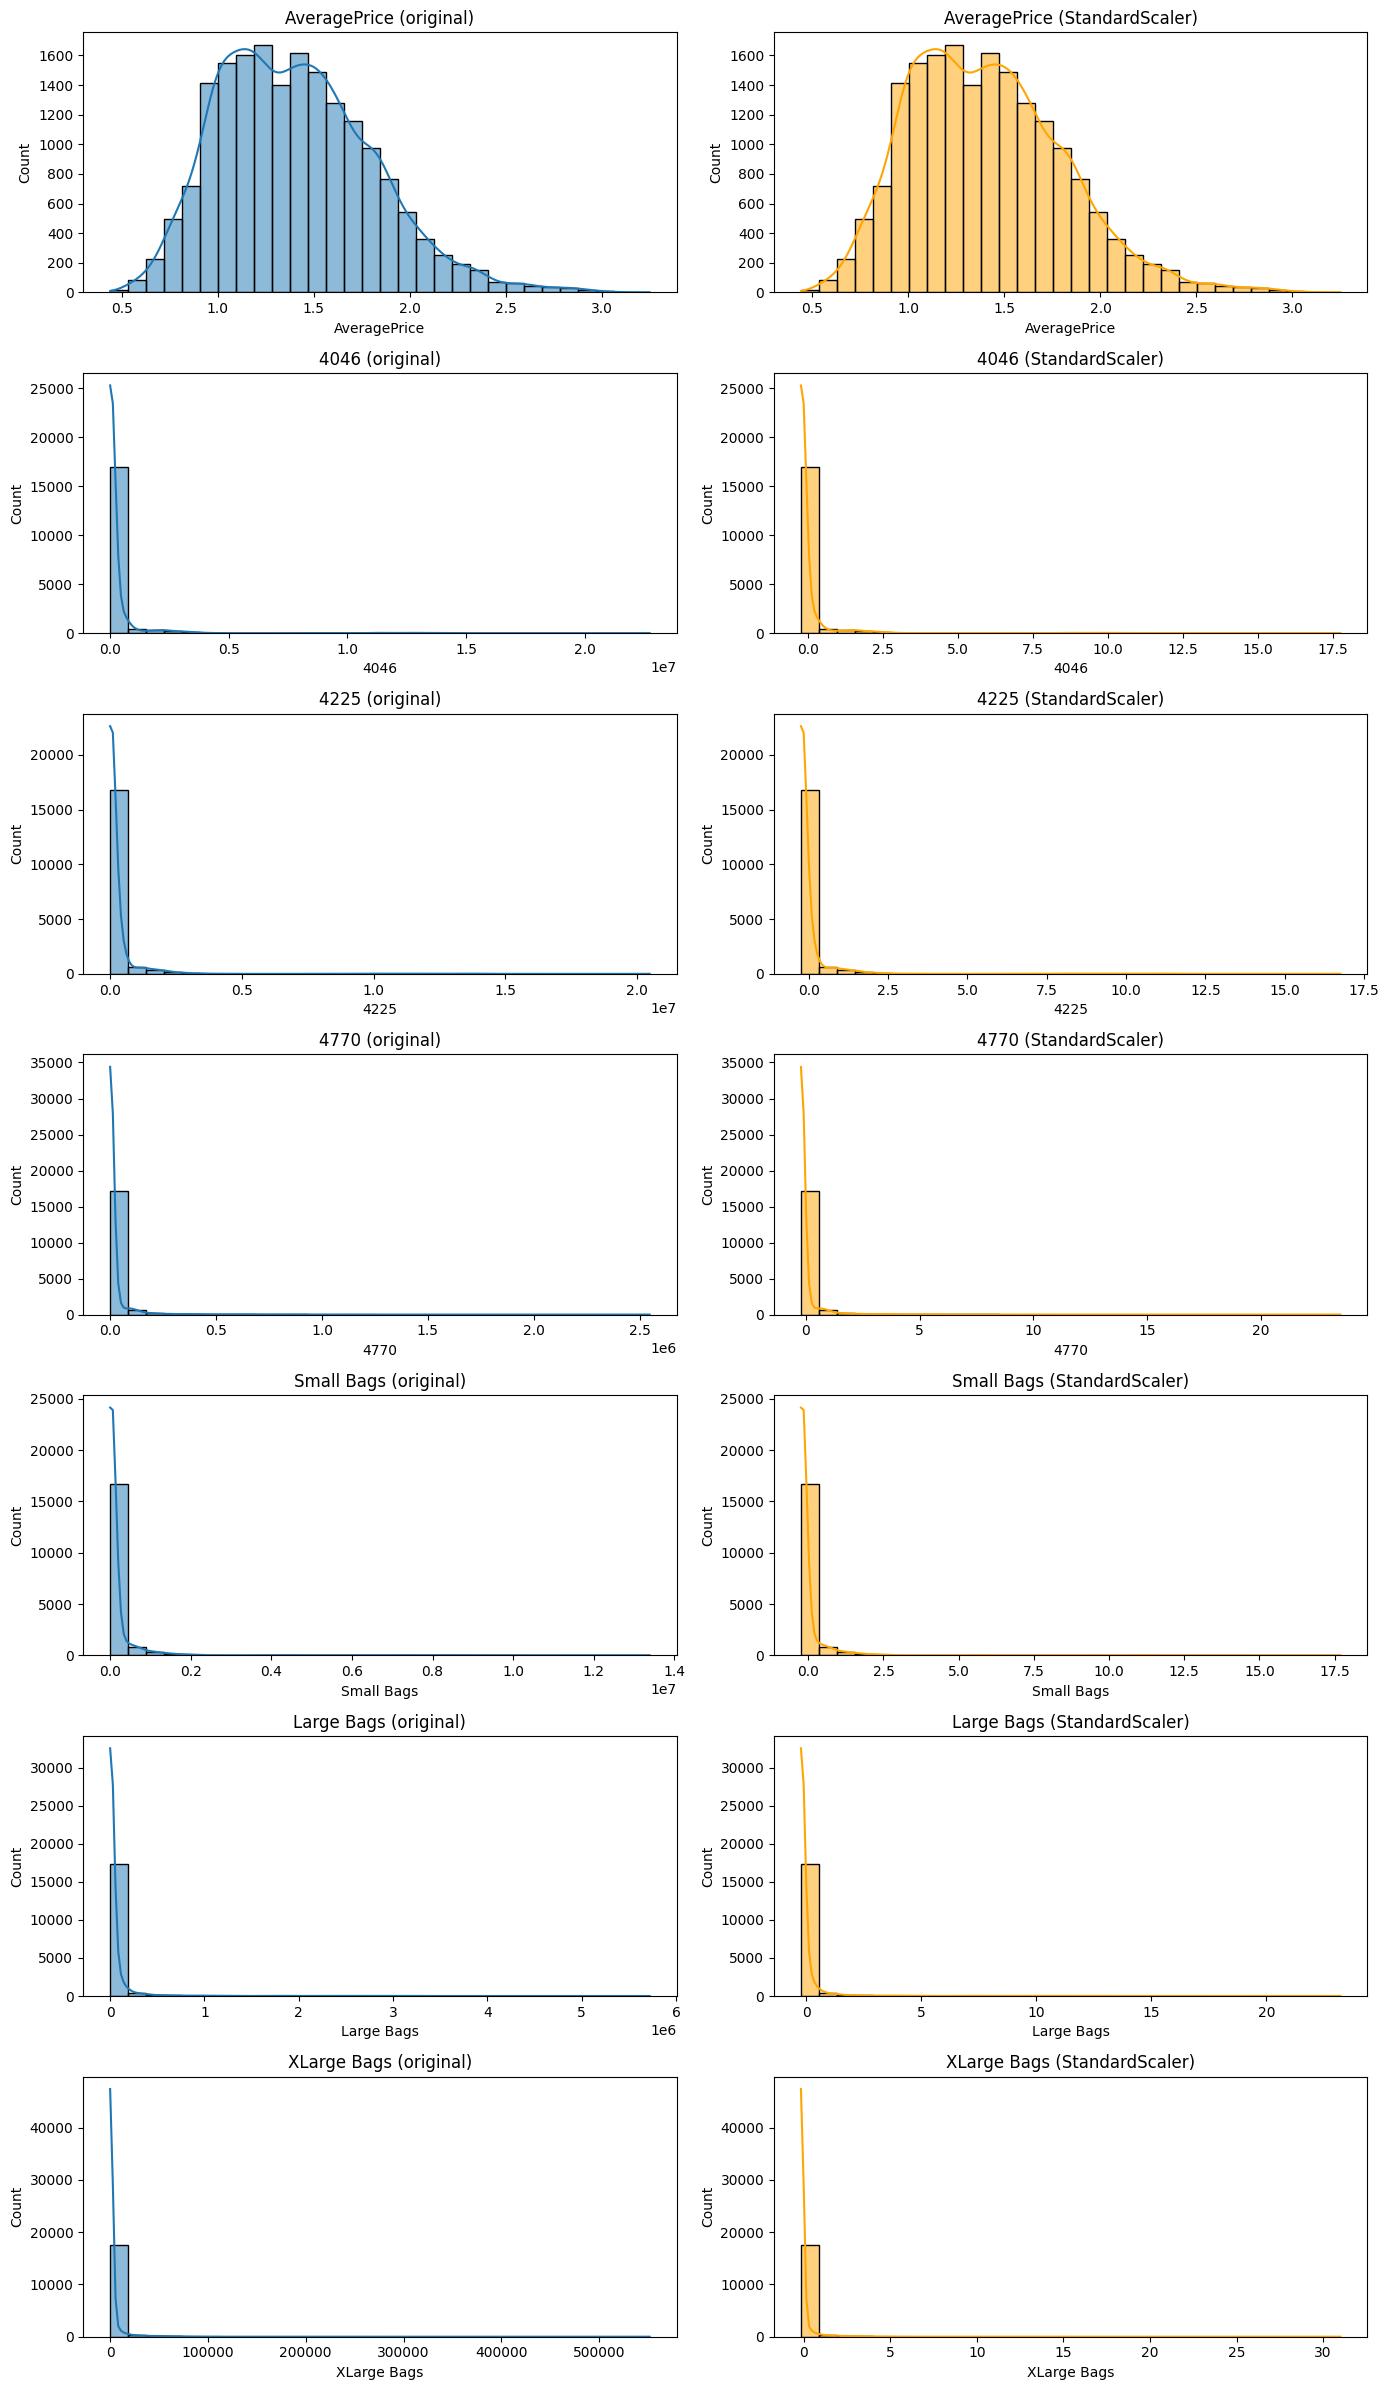

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(7, 2, figsize=(14, 24))

#AveragePrice
sns.histplot(df['AveragePrice'], kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('AveragePrice (original)')
sns.histplot(df_clean['AveragePrice'], kde=True, bins=30, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('AveragePrice (StandardScaler)')

#4046
sns.histplot(df['4046'], kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('4046 (original)')
sns.histplot(df_clean['4046'], kde=True, bins=30, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('4046 (StandardScaler)')

#4225
sns.histplot(df['4225'], kde=True, bins=30, ax=axes[2, 0])
axes[2, 0].set_title('4225 (original)')
sns.histplot(df_clean['4225'], kde=True, bins=30, color='orange', ax=axes[2, 1])
axes[2, 1].set_title('4225 (StandardScaler)')

#4770
sns.histplot(df['4770'], kde=True, bins=30, ax=axes[3, 0])
axes[3, 0].set_title('4770 (original)')
sns.histplot(df_clean['4770'], kde=True, bins=30, color='orange', ax=axes[3, 1])
axes[3, 1].set_title('4770 (StandardScaler)')

#Small Bags
sns.histplot(df['Small Bags'], kde=True, bins=30, ax=axes[4, 0])
axes[4, 0].set_title('Small Bags (original)')
sns.histplot(df_clean['Small Bags'], kde=True, bins=30, color='orange', ax=axes[4, 1])
axes[4, 1].set_title('Small Bags (StandardScaler)')

#Large Bags
sns.histplot(df['Large Bags'], kde=True, bins=30, ax=axes[5, 0])
axes[5, 0].set_title('Large Bags (original)')
sns.histplot(df_clean['Large Bags'], kde=True, bins=30, color='orange', ax=axes[5, 1])
axes[5, 1].set_title('Large Bags (StandardScaler)')

#XLarge Bags
sns.histplot(df['XLarge Bags'], kde=True, bins=30, ax=axes[6, 0])
axes[6, 0].set_title('XLarge Bags (original)')
sns.histplot(df_clean['XLarge Bags'], kde=True, bins=30, color='orange', ax=axes[6, 1])
axes[6, 1].set_title('XLarge Bags (StandardScaler)')

plt.tight_layout()
plt.show()

In [165]:
df_clean.to_csv('avocado_clean.csv', index=False)